# EEG-Based Age Classification — Dortmund Vital Study Resting-State EEG
## Notebook 00: Environment Verification & Metadata Exploration

**Dataset:** DS005385 — Resting-state EEG data before and after cognitive activity across the adult lifespan and a 5-year follow-up
**Source:** OpenNeuro, accessed directly from its public AWS S3 bucket (`s3://openneuro.org/ds005385`)
**Citation:** Wascher, E., Schneider, D., Gajewski, P. D., & Getzmann, S. Resting-state EEG data before and after cognitive activity across the adult lifespan and a 5-year follow-up. OpenNeuro. https://doi.org/10.18112/openneuro.ds005385.v1.0.3
**License:** CC0

### Purpose
This notebook performs three preparatory tasks required before any EEG signal processing begins:
1. Verify that the Python environment contains all dependencies needed for the project.
2. Retrieve and inspect subject-level metadata (age, sex, handedness) for this dataset's 608 participants.
3. Define a clean, well-justified analysis cohort: one recording per subject, split into young and old age groups.

### Rationale
This dataset contains resting-state EEG recorded from 608 healthy adults aged 20-70, with eyes-open and eyes-closed conditions captured before and after a 2-hour block of cognitive tasks, at a baseline session and, for a subset of participants, a 5-year follow-up session. Before any signal processing, the analysis must be narrowed to exactly one well-defined recording per subject, and a binary young/old grouping must be established from the continuous age variable. These are the two questions this notebook answers.

## Execution Environment: Google Colab (via VS Code)

This notebook file lives locally in this project's `notebooks/` folder, but its **kernel** — where the code executes — is a remote Google Colab virtual machine, connected through the Google Colab extension for VS Code. This is used for its fast cloud bandwidth when downloading EEG recordings.

Two practical consequences:

1. **Paths point to the remote VM's disk, not the local machine** — this notebook uses `/content/data` and `/content/figures`.
2. **The remote disk is temporary.** Files written to `/content/...` are lost when the session disconnects, since Google Drive mounting is not yet supported by this extension. Small derived artifacts this project needs to keep (e.g. `cohort_labels.csv`) are explicitly downloaded to the local machine at the end of this notebook.

**To connect:** Select Kernel → Select Another Kernel... → Colab → sign in → New Colab Server.

In [1]:
"""
Colab remote-kernel setup.

Installs MNE-Python at a pinned version (numpy, pandas, matplotlib,
scikit-learn and requests already ship with the default Colab
runtime). Defines shared path variables, including the base URL of
this dataset on OpenNeuro's public S3 bucket, and enables inline
plotting.
"""

!pip install -q mne==1.13.2

import os

%matplotlib inline
import matplotlib.pyplot as plt

DATA_DIR = "/content/data"
FIGURES_DIR = "/content/figures"
OPENNEURO_BASE_URL = "https://s3.amazonaws.com/openneuro.org/ds005385"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Remote kernel working directory:", os.getcwd())
print("Data directory    :", DATA_DIR)
print("Figures directory :", FIGURES_DIR)
print("Dataset source    :", OPENNEURO_BASE_URL)

Remote kernel working directory: /content
Data directory    : /content/data
Figures directory : /content/figures
Dataset source    : https://s3.amazonaws.com/openneuro.org/ds005385


## Step 1 — Environment Verification

Imports every library required across the full project pipeline and prints its installed version, confirming the kernel is correctly connected before proceeding.

In [2]:
"""
Environment verification. Imports all core dependencies used
throughout this project and prints their installed versions.
"""

import sys
import numpy as np
import pandas as pd
import matplotlib
import sklearn
import mne
import requests

print(f"Python version       : {sys.version.split()[0]}")
print(f"numpy version        : {np.__version__}")
print(f"pandas version       : {pd.__version__}")
print(f"matplotlib version   : {matplotlib.__version__}")
print(f"scikit-learn version : {sklearn.__version__}")
print(f"mne version          : {mne.__version__}")
print(f"requests version     : {requests.__version__}")

Python version       : 3.13.15
numpy version        : 2.1.3
pandas version       : 2.2.3
matplotlib version   : 3.10.0
scikit-learn version : 1.6.1
mne version          : 1.13.2
requests version     : 2.32.4


## Step 2 — Load Participant Metadata from OpenNeuro

Every BIDS dataset includes a `participants.tsv` file at its root, with one row per participant and their demographic information. It is read here directly from OpenNeuro's public S3 bucket, which requires no account or credentials. No EEG signal data is downloaded at this stage.

In [3]:
"""
Read the dataset's participants.tsv directly from OpenNeuro's public
S3 bucket. participant_id is read as a string to preserve zero-padded
IDs (e.g. "sub-001"); "n/a" entries are parsed as missing values.
"""

participants_url = f"{OPENNEURO_BASE_URL}/participants.tsv"
participants = pd.read_csv(participants_url, sep="\t", dtype={"participant_id": str})

print(f"Participants loaded: {len(participants)}")

Participants loaded: 608


## Step 3 — Inspect Available Metadata Fields

The columns of `participants.tsv` are inspected directly rather than assumed, to confirm which demographic fields are available and how complete they are.

In [4]:
"""
Inspect the columns and first rows of the participant metadata table.
"""

print("Available metadata columns:")
print(participants.columns.tolist())

participants.head(10)

Available metadata columns:
['participant_id', 'sex', 'age', 'handedness', 'session1', 'late_ses1', 'session2', 'late_ses2']


,participant_id,sex,age,handedness,session1,late_ses1,session2,late_ses2
0,sub-001,F,60,right,yes,0,yes,0.0
1,sub-002,M,67,right,yes,0,no,NaN
2,sub-003,F,44,right,yes,0,no,NaN
3,sub-004,F,24,right,yes,0,no,NaN
4,sub-005,F,48,right,yes,0,yes,5.0
5,sub-006,F,57,right,yes,0,no,NaN
6,sub-007,F,24,right,yes,0,no,NaN
7,sub-008,M,39,left,yes,1901,no,NaN
8,sub-009,F,37,right,yes,2080,no,NaN
9,sub-010,F,23,right,yes,0,no,NaN


In [5]:
"""
Inspect data types and check for missing values in the key
demographic columns.
"""

print(participants.dtypes)
print()
print("Missing values per column:")
print(participants[["age", "sex", "handedness", "session1"]].isna().sum())

participant_id     object
sex                object
age                 int64
handedness         object
session1           object
late_ses1           int64
session2           object
late_ses2         float64
dtype: object

Missing values per column:
age           0
sex           0
handedness    2
session1      0
dtype: int64


## Step 4 — Define One Recording Per Subject

Each participant has several resting-state recordings, for three reasons: a baseline session and, for some participants, a 5-year follow-up session; two conditions (`EyesClosed`, `EyesOpen`); and, within each session and condition, two acquisitions distinguished by the `acq` label in the BIDS filename. According to the dataset's own metadata, `acq-pre` was recorded before a battery of neurocognitive experiments lasting about 2 hours, and `acq-post` after it.

This project uses the **baseline session (session 1)**, **eyes-closed** condition, **pre-task** acquisition. Eyes-closed rest is the standard condition for alpha-band analysis in the aging literature; restricting to session 1 avoids counting a subject twice; and the pre-task recording is the undisturbed resting baseline, whereas the post-task recording reflects mental fatigue, an uncontrolled confound for an age classifier. Because BIDS filenames are fully determined by these labels, the exact file for each subject is constructed explicitly here rather than looked up.

In [6]:
"""
Confirm every participant completed session 1, then construct the
path of each subject's analysis recording: session 1, eyes-closed,
pre-task acquisition. This path is stored with the cohort so later
notebooks use exactly the same file for every subject.
"""

n_with_session1 = (participants["session1"] == "yes").sum()
print(f"Participants with a session-1 measurement: {n_with_session1} of {len(participants)}")

participants = participants[participants["session1"] == "yes"].copy()
participants["subject"] = participants["participant_id"].str.replace("sub-", "", regex=False)
participants["recording"] = (
    "sub-" + participants["subject"] + "/ses-1/eeg/"
    + "sub-" + participants["subject"] + "_ses-1_task-EyesClosed_acq-pre_eeg.edf"
)

print("Example recording path:", participants["recording"].iloc[0])

Participants with a session-1 measurement: 608 of 608
Example recording path: sub-001/ses-1/eeg/sub-001_ses-1_task-EyesClosed_acq-pre_eeg.edf


## Step 5 — Define Young/Old Age Groups

This dataset's age variable is continuous (20-70 years), unlike some resting-state EEG datasets that are collected with a built-in bimodal young/old design. A binary grouping is defined here using a **percentile split**: the youngest third of subjects are labeled `young`, the oldest third `old`, and the middle third is excluded.

This mirrors the design used by studies that deliberately contrast clearly young and clearly old groups rather than splitting at a single median threshold — a median split would place two 45-year-olds on opposite sides of the boundary despite near-identical expected brain activity, blurring the signal a classifier is meant to detect. A percentile split is also fully data-driven and reproducible, adapting automatically to this cohort's actual age distribution rather than relying on externally imposed cutoffs.

In [7]:
"""
Define binary age groups using a percentile split on the continuous
age variable: bottom third = "young", top third = "old", middle third
excluded.
"""

ages = participants["age"].dropna()
young_cutoff = ages.quantile(1 / 3)
old_cutoff = ages.quantile(2 / 3)

print(f"Age distribution: min={ages.min():.0f}, median={ages.median():.0f}, max={ages.max():.0f}")
print(f"Young cutoff (33rd percentile): age <= {young_cutoff:.0f}")
print(f"Old cutoff (67th percentile)  : age >= {old_cutoff:.0f}")


def assign_age_group(age):
    if pd.isna(age):
        return None
    if age <= young_cutoff:
        return "young"
    if age >= old_cutoff:
        return "old"
    return None  # middle third - excluded to sharpen the young/old contrast


participants["age_group"] = participants["age"].apply(assign_age_group)
cohort = participants.dropna(subset=["age_group"]).copy()

print(f"\nSubjects retained after young/old split: {len(cohort)}")
print(cohort["age_group"].value_counts())

Age distribution: min=20, median=46, max=70
Young cutoff (33rd percentile): age <= 34
Old cutoff (67th percentile)  : age >= 52

Subjects retained after young/old split: 416
age_group
old      213
young    203
Name: count, dtype: int64


## Step 6 — Visualize the Age Distribution

The age distribution and the young/old split thresholds are plotted for visual confirmation, and saved for inclusion in this project's written summary and GitHub repository.

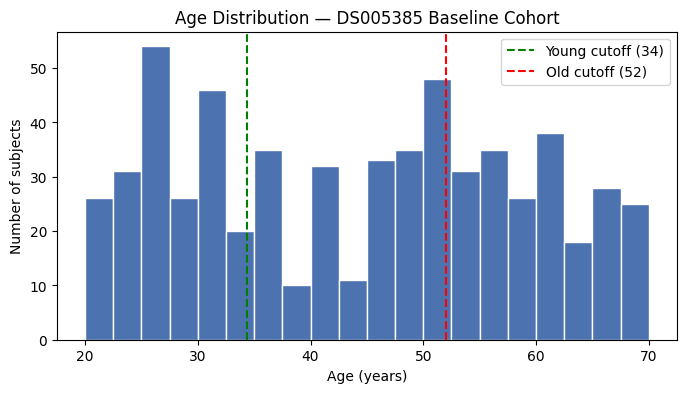

In [8]:
"""
Plot the age distribution with the young/old split thresholds marked.
"""

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ages, bins=20, color="#4C72B0", edgecolor="white")
ax.axvline(young_cutoff, color="green", linestyle="--", label=f"Young cutoff ({young_cutoff:.0f})")
ax.axvline(old_cutoff, color="red", linestyle="--", label=f"Old cutoff ({old_cutoff:.0f})")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of subjects")
ax.set_title("Age Distribution — DS005385 Baseline Cohort")
ax.legend()

fig.savefig(f"{FIGURES_DIR}/00_age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 7 — Persist Cohort Labels

The final cohort (one recording per subject, labeled young/old) is saved as a standalone CSV artifact, decoupling the next notebook from re-running this metadata pipeline.

In [9]:
"""
Persist the final labeled cohort to disk, including each subject's
recording path. The 'subject' column is written as a string to
preserve zero-padded IDs.
"""

cohort_labels_path = f"{DATA_DIR}/cohort_labels.csv"

cohort[["subject", "age", "sex", "handedness", "age_group", "recording"]].to_csv(
    cohort_labels_path, index=False
)

print(f"Saved {len(cohort)} labeled subjects to {cohort_labels_path}")

Saved 416 labeled subjects to /content/data/cohort_labels.csv


## Step 8 — Retrieve Cohort Labels and Figure for Local Use

`cohort_labels.csv` and the age-distribution figure are downloaded to the local machine here, since files on the Colab VM's disk are lost when this session ends.


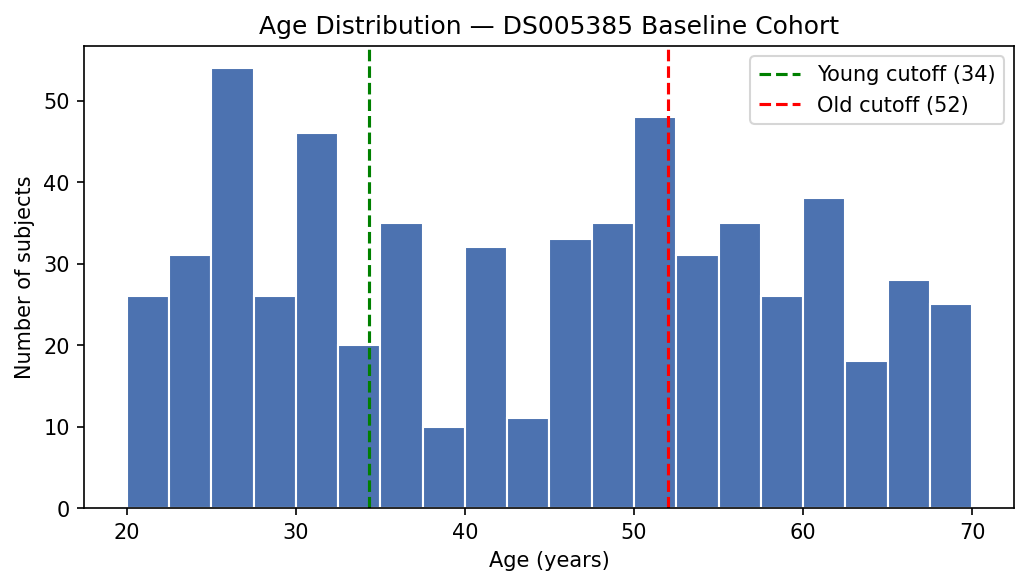

In [10]:
"""
Generate browser download links for files on the remote Colab VM's
disk, since they are lost when the session disconnects.
"""

import base64
import mimetypes
from IPython.display import HTML

def download_link(filepath):
    filename = filepath.split("/")[-1]
    mime_type, _ = mimetypes.guess_type(filepath)
    mime_type = mime_type or "application/octet-stream"
    with open(filepath, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    return HTML(f'<a download="{filename}" href="data:{mime_type};base64,{b64}">Download {filename}</a>')

display(download_link(cohort_labels_path))
display(download_link(f"{FIGURES_DIR}/00_age_distribution.png"))

## Summary

Participant metadata for DS005385 was read directly from OpenNeuro, and one recording was defined per subject (baseline session, eyes-closed, pre-task). A binary young/old grouping was derived from the continuous age variable using a percentile split: the youngest and oldest thirds were retained and the middle third excluded to sharpen the group contrast. The resulting 416-subject cohort (203 young, 213 old), including each subject's recording path, was saved to `cohort_labels.csv` and downloaded locally, alongside a figure documenting the age distribution and split thresholds.

The next notebook (`01_subject_subset_selection_and_data_access.ipynb`) downloads these recordings from OpenNeuro.